# Visium HD CRC — deconvolution metadata overview

RCTD doublet-mode results for 8 µm bins (`P{1,2,5}CRC_Metadata.parquet`) plus the
Chromium Flex single-cell hierarchy (`SingleCell_MetaData_2025.csv`).

This notebook uses **one cell type per bin**: `DeconvolutionLabel1` (RCTD first type, Level2).
`DeconvolutionLabel2` is ignored.

| Column | Meaning |
|--------|---------|
| `DeconvolutionClass` | RCTD spot class: `singlet` / `doublet_certain` / `doublet_uncertain` / `reject` / missing (off-tissue) |
| `DeconvolutionLabel1` | **Cell type used here** — RCTD first type, a **Level2** label (not Level1) |

Deconvolution was run on **Level2** (`Deconvolution_LLY.R`: `CTRef <- MetaData$Level2`).
Level1 is recovered by mapping `DeconvolutionLabel1` to its majority Flex parent (`L1_from_Label1`).

This notebook:

1. Summarizes **P2CRC** deconvolution (class mix, Label1 L2 / mapped L1).
2. Walks **P1CRC → P2CRC → P5CRC** and checks whether Label1 L2 inventories
   and L2→L1 mapping are consistent across patients.
3. Spatial maps from `P{1,2,5}CRC_Metadata.parquet`: RCTD L1, unsupervised L1,
   tumor 50 µm periphery, macrophage subtypes, Goblet subclusters.
4. Xenium companion (`Xenium_P{1,2,5}_cell_info.csv`): no per-cell type labels;
   compare QC and spatial overlap with Visium HD 8 µm bins, then the RCTD
   Label1 / L1 / periphery composition of bins that receive Xenium cells.
5. Transfer Visium HD singlet `DeconvolutionLabel1` onto P2 Xenium cells and
   write `data/Xemium/CRC/Annotation/CRC_Barcode_Cell_Type_Matrices.xlsx`.


In [1]:
## 2026.09.14 LLY: deconvolution overview; one cell type = DeconvolutionLabel1 (ignore Label2)
## Env: SeededNTM
## Visium HD bins: P{1,2,5}CRC_Metadata.parquet only (DeconvolutionResults_*.csv removed)


In [2]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

_candidates = [
    Path("/home/lingyu/ssd2/Python/Hist2Pheno/code/Xenium_crc"),
    Path("/nobackup2/users/lingyu/Python/Hist2Pheno/code/Xenium_crc"),
    Path.cwd() / "code" / "Xenium_crc",
    Path.cwd(),
]
CRC_CODE = next(p for p in _candidates if (p / "crc_paths.py").is_file())
if str(CRC_CODE) not in sys.path:
    sys.path.insert(0, str(CRC_CODE))

from crc_paths import (
    CrcPaths,
    PATIENTS,
    L1_ORDER,
    L1_COLORS,
    L2_ORDER,
    L2_COLORS,
    CLASS_ORDER,
    CLASS_COLORS,
    PERIPH_ORDER,
    PERIPH_COLORS,
    UNSUP_COLORS,
    MAC_COLORS,
    GOBLET_COLORS,
    PATIENT_COLORS,
    majority_l2_to_l1,
    read_bin_meta,
    load_all_bin_meta,
    print_label_types,
    class_table,
    patient_report,
    on_tissue,
    periphery_summary,
    load_xenium_cells,
    map_xenium_to_bins,
    label_xenium_from_visium,
    map_status_table,
    compare_mapped_vs_visium,
    overlap_row,
)
from CRC_plot import (
    configure_matplotlib,
    scatter_cats,
    scatter_periphery,
    axis_legend,
    subsample_df,
)

configure_matplotlib()
paths = CrcPaths()
REPO = paths.repo
CRC_DIR = paths.crc_dir
META_DIR = paths.meta_dir
BIN_META_PATHS = paths.bin_meta_paths
SC_PATH = paths.sc_path
SC_PATH_2024 = paths.sc_path_2024
print("REPO:", REPO)
print("META:", META_DIR)


REPO: /nobackup2/users/lingyu/Python/Hist2Pheno
META: /nobackup2/users/lingyu/Python/Hist2Pheno/code/Xenium_crc/HumanColonCancer_VisiumHD/MetaData


## 0. Flex single-cell L1 / L2 hierarchy (reference)

`SingleCell_MetaData_2025.csv` is the Hist2Pheno annotation (README: 2025 release).
Each L2 subtype is assigned to one L1 parent by **majority vote** among `QCFilter == Keep`
cells. Low-purity L2 types (projection noise from Seurat `ProjectData`) are flagged.


In [3]:
sc = pd.read_csv(SC_PATH)
print("Single-cell 2025:", sc.shape, "columns:", list(sc.columns))
print("Patients:\n", sc["Patient"].value_counts().to_string())
print("\nQCFilter:\n", sc["QCFilter"].value_counts(dropna=False).to_string())

keep = sc[sc["QCFilter"] == "Keep"].copy()
print(f"\nKeep cells: {len(keep):,} / {len(sc):,}")
print("L1:", sorted(keep["Level1"].dropna().unique().tolist()))
print("L2 n=", keep["Level2"].nunique(), sorted(keep["Level2"].dropna().unique().tolist()))


Single-cell 2025: (279609, 8) columns: ['Barcode', 'Patient', 'BC', 'QCFilter', 'Level1', 'Level2', 'UMAP1', 'UMAP2']
Patients:
 Patient
P3CRC    50652
P2CRC    41933
P3NAT    41237
P5NAT    36873
P2NAT    32801
P4CRC    31007
P5CRC    24615
P1CRC    20491

QCFilter:
 QCFilter
Keep      260506
Remove     19103

Keep cells: 260,506 / 279,609
L1: ['B cells', 'Endothelial', 'Fibroblast', 'Intestinal Epithelial', 'Myeloid', 'Neuronal', 'Smooth Muscle', 'T cells', 'Tumor']
L2 n= 38 ['Adipocyte', 'CAF', 'CD4 T cell', 'CD8 T cell', 'Endothelial', 'Enteric Glial', 'Enterocyte', 'Epithelial', 'Fibroblast', 'Goblet', 'Lymphatic Endothelial', 'Macrophage', 'Mast', 'Mature B', 'Memory B', 'Myofibroblast', 'NK', 'Neuroendocrine', 'Neutrophil', 'Pericytes', 'Plasma', 'Proliferating Fibroblast', 'Proliferating Immune II', 'Proliferating Macrophages', 'SM Stress Response', 'Smooth Muscle', 'Tuft', 'Tumor I', 'Tumor II', 'Tumor III', 'Tumor IV', 'Tumor V', 'Unknown III (SM)', 'Vascular Fibroblast', 'cD

In [4]:
maj, l2_to_l1, l2_purity = majority_l2_to_l1(keep)

print("Majority L2 → L1 mapping (Keep cells)")
print(
    maj[["Level1", "Level2", "n", "n_total", "purity", "n_alt_L1"]]
    .assign(purity=lambda d: d["purity"].round(3))
    .to_string(index=False)
)

low = maj[maj["purity"] < 0.80]
print(f"\nL2 with majority purity < 0.80: {len(low)}")
if len(low):
    print(low[["Level2", "Level1", "purity", "n_alt_L1"]].to_string(index=False))

n_multi = int((maj["n_alt_L1"] > 1).sum())
print(f"\n{n_multi}/{len(maj)} L2 types appear under >1 L1 in Flex (ProjectData leakage).")
print("Deconvolution analysis uses the majority L1 parent in the table above.")


Majority L2 → L1 mapping (Keep cells)
               Level1                    Level2     n  n_total  purity  n_alt_L1
                Tumor                   Tumor I 25201    27032   0.932         9
                Tumor                  Tumor II  8861     9620   0.921         9
                Tumor                 Tumor III 13049    13128   0.994         7
                Tumor                  Tumor IV  5887     5966   0.987         7
                Tumor                   Tumor V  8161     8208   0.994         8
Intestinal Epithelial                Enterocyte  4413     4440   0.994         6
Intestinal Epithelial                    Goblet 18066    18552   0.974         9
           Fibroblast                 Adipocyte    47       49   0.959         3
           Fibroblast                       CAF 11633    12080   0.963         9
           Fibroblast                Fibroblast 12304    12436   0.989         9
           Fibroblast             Myofibroblast  1674     3351   0.500 

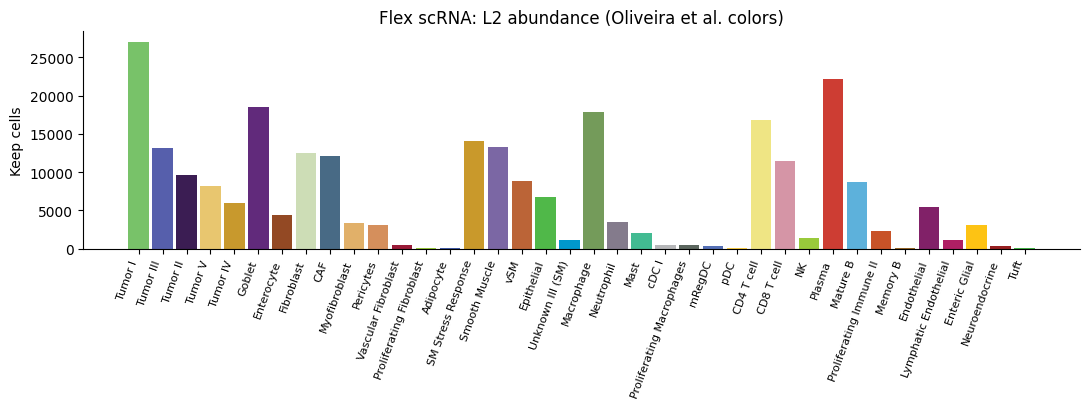

In [5]:
fig, ax = plt.subplots(figsize=(11, 4.2))
order_l2 = maj.sort_values(
    ["Level1", "n_total"],
    key=lambda s: s.map({v: i for i, v in enumerate(L1_ORDER)}) if s.name == "Level1" else s,
    ascending=[True, False],
)
colors = [L2_COLORS.get(l2, "#888888") for l2 in order_l2["Level2"]]
ax.bar(np.arange(len(order_l2)), order_l2["n_total"], color=colors, width=0.85)
ax.set_xticks(np.arange(len(order_l2)))
ax.set_xticklabels(order_l2["Level2"], rotation=70, ha="right", fontsize=8)
ax.set_ylabel("Keep cells")
ax.set_title("Flex scRNA: L2 abundance (Oliveira et al. colors)")
fig.tight_layout()
plt.show()


In [6]:
# 2024 vs 2025 L2 names — deconvolution matches 2025
sc24 = pd.read_csv(SC_PATH_2024)
k24 = sc24[sc24["QCFilter"] == "Keep"]
l2_24 = set(k24["Level2"].dropna().unique())
l2_25 = set(keep["Level2"].dropna().unique())
print("L2 only in 2024:", sorted(l2_24 - l2_25) or "(none)")
print("L2 only in 2025:", sorted(l2_25 - l2_24) or "(none)")
print(f"shared={len(l2_24 & l2_25)}  2024={len(l2_24)}  2025={len(l2_25)}")


L2 only in 2024: ['CD8 Cytotoxic T cell']
L2 only in 2025: ['CD8 T cell', 'Memory B', 'NK', 'Proliferating Fibroblast', 'Proliferating Macrophages', 'Tumor IV', 'Vascular Fibroblast', 'cDC I']
shared=30  2024=31  2025=38


## 1. P2CRC deconvolution — overall statistics

Inspect `P2CRC_Metadata.parquet`, then count distinct types in **`DeconvolutionLabel1` only**
(the cell type used below). Missing `DeconvolutionClass` is off-tissue / not scored.
Assigned bins are RCTD `singlet` / `doublet_*` / `reject`. Label1 is Level2;
Level1 mapping (`L1_from_Label1`) is added afterwards. `DeconvolutionLabel2` is not used.


In [7]:
p2_raw = read_bin_meta(BIN_META_PATHS["P2CRC"])
print("P2CRC parquet", p2_raw.shape)
print("columns:", list(p2_raw.columns))
print("\nDeconvolutionClass:")
print(p2_raw["DeconvolutionClass"].value_counts(dropna=False).to_string())

vc_lab1 = print_label_types(p2_raw["DeconvolutionLabel1"], "DeconvolutionLabel1")


P2CRC parquet (702244, 12)
columns: ['barcode', 'tissue', 'X', 'Y', 'DeconvolutionClass', 'DeconvolutionLabel1', 'DeconvolutionLabel2', 'Periphery', 'UnsupervisedL1', 'UnsupervisedL2', 'MacrophageSubtype', 'GobletSubcluster']

DeconvolutionClass:
DeconvolutionClass
singlet              322327
None                 271240
doublet_certain       45436
doublet_uncertain     37514
reject                25727

DeconvolutionLabel1  (cell type used in this notebook)
  n types (excluding NA) = 38
  n NA bins              = 271,240
  types: ['Adipocyte', 'CAF', 'CD4 T cell', 'CD8 T cell', 'Endothelial', 'Enteric Glial', 'Enterocyte', 'Epithelial', 'Fibroblast', 'Goblet', 'Lymphatic Endothelial', 'Macrophage', 'Mast', 'Mature B', 'Memory B', 'Myofibroblast', 'NK', 'Neuroendocrine', 'Neutrophil', 'Pericytes', 'Plasma', 'Proliferating Fibroblast', 'Proliferating Immune II', 'Proliferating Macrophages', 'SM Stress Response', 'Smooth Muscle', 'Tuft', 'Tumor I', 'Tumor II', 'Tumor III', 'Tumor IV', 'Tu

In [8]:
bin_meta = load_all_bin_meta(paths, l2_to_l1)
p2 = bin_meta["P2CRC"]
print("P2CRC after L1 mapping", p2.shape)
print("columns:", list(p2.columns))
print("L1 from Label1 n types:", p2["L1_from_Label1"].nunique(dropna=True))


P2CRC after L1 mapping (702244, 14)
columns: ['barcode', 'tissue', 'X', 'Y', 'DeconvolutionClass', 'DeconvolutionLabel1', 'DeconvolutionLabel2', 'Periphery', 'UnsupervisedL1', 'UnsupervisedL2', 'MacrophageSubtype', 'GobletSubcluster', 'L1_from_Label1', 'unmapped_L2']
L1 from Label1 n types: 9


In [9]:
print("\nClass mix:")
print(class_table(p2).round(2).to_string())

assigned = p2[p2["DeconvolutionClass"].notna()].copy()
print(f"\nAssigned bins: {len(assigned):,} / {len(p2):,} ({100*len(assigned)/len(p2):.1f}%)")
print("Label1 L2 n=", assigned["DeconvolutionLabel1"].nunique())
unmapped = sorted(set(assigned["DeconvolutionLabel1"].dropna()) - set(l2_to_l1))
print("L2 in deconv but not in scRNA mapping:", unmapped or "(none)")
print("L2 in scRNA but never Label1:", sorted(set(l2_to_l1) - set(assigned["DeconvolutionLabel1"].dropna())) or "(none)")



Class mix:
                         n  pct_all  pct_assigned
DeconvolutionClass                               
singlet             322327    45.90         74.79
doublet_certain      45436     6.47         10.54
doublet_uncertain    37514     5.34          8.70
reject               25727     3.66          5.97
unassigned          271240    38.62           NaN

Assigned bins: 431,004 / 702,244 (61.4%)
Label1 L2 n= 38
L2 in deconv but not in scRNA mapping: (none)
L2 in scRNA but never Label1: (none)


In [10]:
p2.head()

,barcode,tissue,X,Y,DeconvolutionClass,DeconvolutionLabel1,DeconvolutionLabel2,Periphery,UnsupervisedL1,UnsupervisedL2,MacrophageSubtype,GobletSubcluster,L1_from_Label1,unmapped_L2
0,s_008um_00000_00000-1,1,323.656687,-178.351988,None,None,None,Tissue,Smooth Muscle,SmoothMuscle-0,None,None,NaN,False
1,s_008um_00000_00001-1,1,323.889508,-178.355054,singlet,Pericytes,Endothelial,Tissue,Unknown,Endothelial-0,None,None,Fibroblast,False
2,s_008um_00000_00002-1,1,324.122329,-178.358120,None,None,None,Tissue,Endothelial,Endothelial-2,None,None,NaN,False
3,s_008um_00000_00003-1,1,324.355150,-178.361186,None,None,None,Tissue,Unknown,Unknown-3,None,None,NaN,False
4,s_008um_00000_00004-1,1,324.587971,-178.364252,None,None,None,Tissue,Unknown,Unknown-3,None,None,NaN,False


In [11]:
print("P2CRC Label1 (first type) counts — all assigned bins")
lab1 = assigned["DeconvolutionLabel1"].value_counts()
lab1_df = (
    lab1.rename("n")
    .to_frame()
    .assign(
        pct=lambda d: 100 * d["n"] / d["n"].sum(),
        L1=lambda d: d.index.map(l2_to_l1),
        purity=lambda d: d.index.map(l2_purity),
    )
)
print(lab1_df.round(2).to_string())

print("\nP2CRC Label1 rolled up to L1")
l1_vc = assigned["L1_from_Label1"].value_counts().reindex(L1_ORDER)
l1_tab = pd.DataFrame({"n": l1_vc, "pct": 100 * l1_vc / l1_vc.sum()})
print(l1_tab.round(2).to_string())
print("unmapped Label1:", int(assigned["L1_from_Label1"].isna().sum()))


P2CRC Label1 (first type) counts — all assigned bins
                                n    pct                     L1  purity
DeconvolutionLabel1                                                    
Tumor III                  213815  49.61                  Tumor    0.99
CAF                         59322  13.76             Fibroblast    0.96
Goblet                      30300   7.03  Intestinal Epithelial    0.97
Endothelial                 18043   4.19            Endothelial    0.99
Macrophage                  15078   3.50                Myeloid    0.98
vSM                         13225   3.07          Smooth Muscle    0.76
Plasma                      12066   2.80                B cells    0.99
Enterocyte                  10383   2.41  Intestinal Epithelial    0.99
Proliferating Macrophages    9243   2.14                Myeloid    0.85
Proliferating Fibroblast     9164   2.13             Fibroblast    0.99
Myofibroblast                6107   1.42             Fibroblast    0.50
Pericytes  

In [12]:
print("P2CRC class × L1 (from Label1)")
print(
    pd.crosstab(assigned["DeconvolutionClass"], assigned["L1_from_Label1"])
    .reindex(index=CLASS_ORDER, columns=L1_ORDER)
    .to_string()
)


P2CRC class × L1 (from Label1)
L1_from_Label1       Tumor  Intestinal Epithelial  Fibroblast  Smooth Muscle  Myeloid  T cells  B cells  Endothelial  Neuronal
DeconvolutionClass                                                                                                            
singlet             199861                  35357       48189          12948     9034      976     5281        10148       533
doublet_certain       8507                   2647       14581           1016     8365     1101     4247         4702       270
doublet_uncertain     6731                   1441        7416            922     9241     2127     5784         3567       285
reject                 907                   1238       14120           1027     4052     1966      656         1561       200


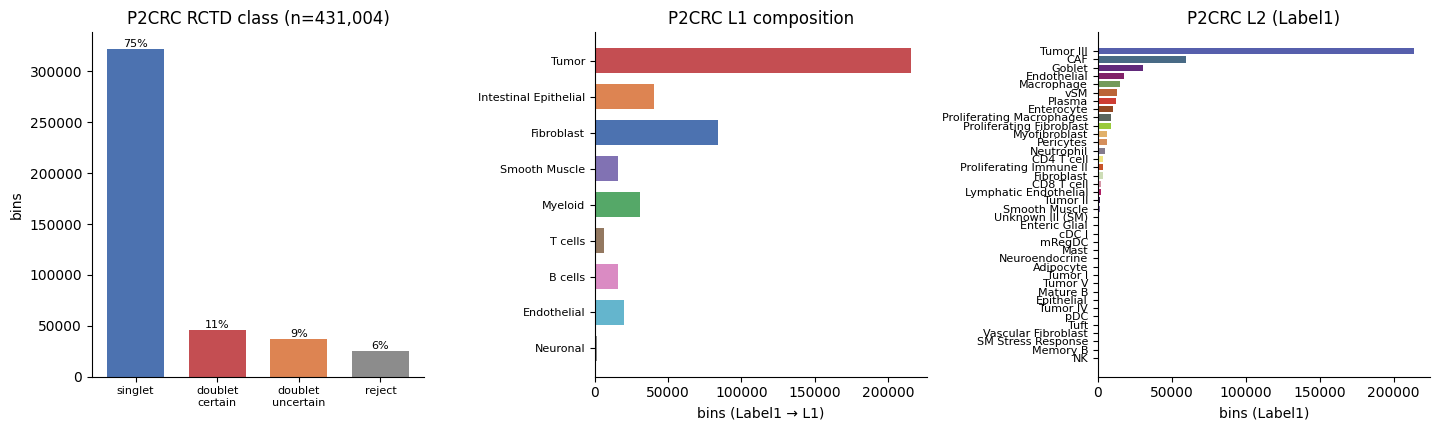

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(14.5, 4.4))

# class
cls = assigned["DeconvolutionClass"].value_counts().reindex(CLASS_ORDER).fillna(0)
axes[0].bar(np.arange(len(cls)), cls.values, color=[CLASS_COLORS[c] for c in cls.index], width=0.7)
axes[0].set_xticks(np.arange(len(cls)))
axes[0].set_xticklabels(["singlet", "doublet\ncertain", "doublet\nuncertain", "reject"], fontsize=8)
axes[0].set_ylabel("bins")
axes[0].set_title(f"P2CRC RCTD class (n={len(assigned):,})")
for i, v in enumerate(cls.values):
    axes[0].text(i, v, f"{100*v/cls.sum():.0f}%", ha="center", va="bottom", fontsize=8)

# L1
l1n = assigned["L1_from_Label1"].value_counts().reindex(L1_ORDER).fillna(0)
axes[1].barh(np.arange(len(l1n))[::-1], l1n.values, color=[L1_COLORS[k] for k in l1n.index], height=0.7)
axes[1].set_yticks(np.arange(len(l1n))[::-1])
axes[1].set_yticklabels(l1n.index, fontsize=8)
axes[1].set_xlabel("bins (Label1 → L1)")
axes[1].set_title("P2CRC L1 composition")

# top L2
# top = lab1.head(18)
top = lab1
l2c = [L2_COLORS.get(x, "#888888") for x in top.index]
axes[2].barh(np.arange(len(top))[::-1], top.values, color=l2c, height=0.75)
axes[2].set_yticks(np.arange(len(top))[::-1])
axes[2].set_yticklabels(top.index, fontsize=8)
axes[2].set_xlabel("bins (Label1)")
axes[2].set_title("P2CRC L2 (Label1)")
# axes[2].set_title("P2CRC top L2 (Label1)")

fig.tight_layout()
plt.show()


In [14]:
# Cell type for all plots below is DeconvolutionLabel1.
# RCTD also writes DeconvolutionLabel2 in the parquet; it is not used.


## 2. P1CRC / P2CRC / P5CRC — is Label1 L2 / mapped L1 consistent?

For each patient, in order: Label1 L2 inventory, L1 inventory after mapping Label1,
then a cross-patient comparison. `DeconvolutionLabel2` is not used.

A consistent hierarchy means:

- the same Label1 L2 names appear in all three parquet tables
- every Label1 L2 maps to one L1 in the Flex metadata
- that L2→L1 map does not depend on the Visium patient (it comes from Flex, shared)
- L1 sets after mapping are therefore also the same; **abundances** may differ


In [15]:
reports = {}
for p in PATIENTS:
    reports[p] = patient_report(p, bin_meta[p], l2_to_l1)


P1CRC  bins=702,244  assigned=311,374 (44.3%)
- class
                         n  pct_all  pct_assigned
DeconvolutionClass                               
singlet             235547    33.54         75.65
doublet_certain      15738     2.24          5.05
doublet_uncertain    21976     3.13          7.06
reject               38113     5.43         12.24
unassigned          390870    55.66           NaN
- unique L2 Label1=38
- unique L1 from Label1=9  ['Tumor', 'Intestinal Epithelial', 'Fibroblast', 'Smooth Muscle', 'Myeloid', 'T cells', 'B cells', 'Endothelial', 'Neuronal']
- L2 not in Flex mapping: (none)
- Label1 → L1
L1_from_Label1
Tumor                    41.53
Intestinal Epithelial    15.80
Fibroblast               20.68
Smooth Muscle             1.89
Myeloid                   5.81
T cells                   4.26
B cells                   4.47
Endothelial               5.07
Neuronal                  0.49
- top Label1 L2: Tumor II (126,744), CAF (42,089), Goblet (40,539), Endothelial 

In [16]:
print("L2 inventory (Label1) vs Flex 2025 reference")
flex_l2 = set(l2_to_l1)
rows = []
for p in PATIENTS:
    r = reports[p]
    rows.append({
        "patient": p,
        "n_L2_Label1": len(r["l2_label1"]),
        "n_L1_from_Label1": len(r["l1_label1"]),
        "L2 missing vs Flex": sorted(flex_l2 - r["l2_label1"]) or "—",
        "L2 extra vs Flex": r["unmapped"] or "—",
        "L1 missing vs Flex": [x for x in L1_ORDER if x not in r["l1_label1"]] or "—",
    })
inv = pd.DataFrame(rows)
print(inv.to_string(index=False))

print("\nPairwise L2 (Label1) set equality")
for a, b in [("P1CRC", "P2CRC"), ("P2CRC", "P5CRC"), ("P1CRC", "P5CRC")]:
    sa, sb = reports[a]["l2_label1"], reports[b]["l2_label1"]
    print(f"  {a} vs {b}: equal={sa==sb}  only_{a}={sorted(sa-sb) or '—'}  only_{b}={sorted(sb-sa) or '—'}")

print("\nPairwise L1 (from Label1) set equality")
for a, b in [("P1CRC", "P2CRC"), ("P2CRC", "P5CRC"), ("P1CRC", "P5CRC")]:
    sa, sb = reports[a]["l1_label1"], reports[b]["l1_label1"]
    print(f"  {a} vs {b}: equal={sa==sb}  only_{a}={sorted(sa-sb) or '—'}  only_{b}={sorted(sb-sa) or '—'}")

print("\nL2→L1 map is shared (Flex majority), so L1 labels are consistent by construction")
print(f"if every deconv L2 is in the map. Unmapped L2 across patients: "
      f"{sorted({u for r in reports.values() for u in r['unmapped']}) or '(none)'}")


L2 inventory (Label1) vs Flex 2025 reference
patient  n_L2_Label1  n_L1_from_Label1 L2 missing vs Flex L2 extra vs Flex L1 missing vs Flex
  P1CRC           38                 9                  —                —                  —
  P2CRC           38                 9                  —                —                  —
  P5CRC           38                 9                  —                —                  —

Pairwise L2 (Label1) set equality
  P1CRC vs P2CRC: equal=True  only_P1CRC=—  only_P2CRC=—
  P2CRC vs P5CRC: equal=True  only_P2CRC=—  only_P5CRC=—
  P1CRC vs P5CRC: equal=True  only_P1CRC=—  only_P5CRC=—

Pairwise L1 (from Label1) set equality
  P1CRC vs P2CRC: equal=True  only_P1CRC=—  only_P2CRC=—
  P2CRC vs P5CRC: equal=True  only_P2CRC=—  only_P5CRC=—
  P1CRC vs P5CRC: equal=True  only_P1CRC=—  only_P5CRC=—

L2→L1 map is shared (Flex majority), so L1 labels are consistent by construction
if every deconv L2 is in the map. Unmapped L2 across patients: (none)


Assigned-bin class counts
DeconvolutionClass  singlet  doublet_certain  doublet_uncertain  reject
P1CRC                235547            15738              21976   38113
P2CRC                322327            45436              37514   25727
P5CRC                252456            62177              39696   38007

% of assigned bins
DeconvolutionClass  singlet  doublet_certain  doublet_uncertain  reject
P1CRC                  75.6              5.1                7.1    12.2
P2CRC                  74.8             10.5                8.7     6.0
P5CRC                  64.3             15.8               10.1     9.7


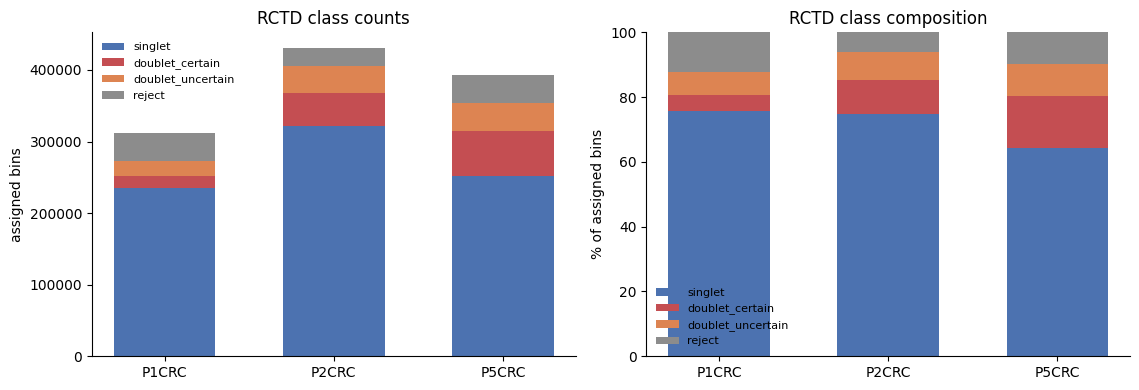

In [17]:
# class mix across patients
class_n = pd.DataFrame({p: reports[p]["class_n"] for p in PATIENTS}).T
class_n = class_n.reindex(columns=CLASS_ORDER).fillna(0).astype(int)
class_pct = class_n.div(class_n.sum(axis=1), axis=0) * 100
print("Assigned-bin class counts")
print(class_n.to_string())
print("\n% of assigned bins")
print(class_pct.round(1).to_string())

fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.0))
x = np.arange(len(PATIENTS))
bottom = np.zeros(len(PATIENTS))
for cls in CLASS_ORDER:
    v = class_n[cls].to_numpy()
    axes[0].bar(x, v, bottom=bottom, color=CLASS_COLORS[cls], width=0.6, label=cls)
    bottom += v
axes[0].set_xticks(x)
axes[0].set_xticklabels(PATIENTS)
axes[0].set_ylabel("assigned bins")
axes[0].set_title("RCTD class counts")
axes[0].legend(frameon=False, fontsize=8)

bottom = np.zeros(len(PATIENTS))
for cls in CLASS_ORDER:
    v = class_pct[cls].to_numpy()
    axes[1].bar(x, v, bottom=bottom, color=CLASS_COLORS[cls], width=0.6, label=cls)
    bottom += v
axes[1].set_xticks(x)
axes[1].set_xticklabels(PATIENTS)
axes[1].set_ylabel("% of assigned bins")
axes[1].set_ylim(0, 100)
axes[1].set_title("RCTD class composition")
axes[1].legend(frameon=False, fontsize=8)
fig.tight_layout()
plt.show()


L2 % of assigned bins (Label1), rows grouped by majority L1
                           P1CRC  P2CRC  P5CRC                     L1
DeconvolutionLabel1                                                  
Tumor II                   40.70   0.36   1.53                  Tumor
Tumor V                     0.48   0.06   2.86                  Tumor
Tumor III                   0.26  49.61   1.44                  Tumor
Tumor I                     0.05   0.06   0.21                  Tumor
Tumor IV                    0.03   0.03  20.92                  Tumor
Goblet                     13.02   7.03  17.20  Intestinal Epithelial
Enterocyte                  2.78   2.41   4.65  Intestinal Epithelial
CAF                        13.52  13.76   7.88             Fibroblast
Fibroblast                  2.54   0.78   5.51             Fibroblast
Pericytes                   1.64   1.39   2.23             Fibroblast
Myofibroblast               1.47   1.42   1.96             Fibroblast
Proliferating Fibroblast    1.

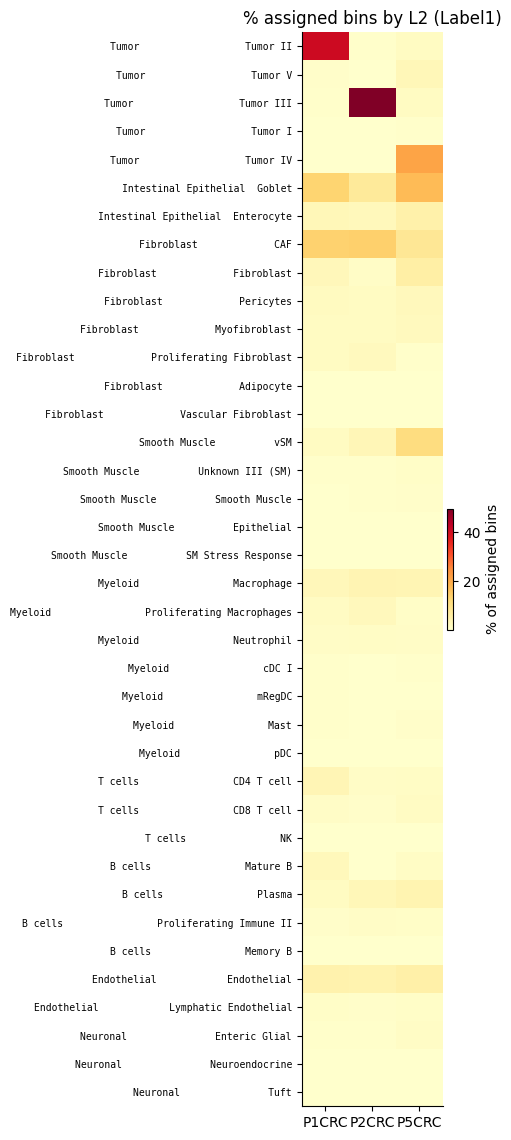

In [18]:
l2_all = sorted(flex_l2)
l2_pct = pd.DataFrame(
    {p: 100 * reports[p]["l2_n"].reindex(l2_all).fillna(0) / reports[p]["n_assigned"] for p in PATIENTS}
)
l2_pct["L1"] = [l2_to_l1[x] for x in l2_pct.index]
l2_pct["_k"] = l2_pct["L1"].map({v: i for i, v in enumerate(L1_ORDER)})
l2_pct = (
    l2_pct.sort_values(["_k"] + PATIENTS, ascending=[True] + [False] * len(PATIENTS))
    .drop(columns="_k")
)

print("L2 % of assigned bins (Label1), rows grouped by majority L1")
print(l2_pct.round(2).to_string())

mat = l2_pct[PATIENTS].astype(float).to_numpy()
fig, ax = plt.subplots(figsize=(5.2, 11.5))
im = ax.imshow(mat, aspect="auto", cmap="YlOrRd")
ax.set_xticks(np.arange(len(PATIENTS)))
ax.set_xticklabels(PATIENTS)
ax.set_yticks(np.arange(len(l2_pct)))
ax.set_yticklabels(
    [f"{l2_to_l1[i]:<22} {i}" for i in l2_pct.index],
    fontsize=7,
    fontfamily="monospace",
)
ax.set_title("% assigned bins by L2 (Label1)")
fig.colorbar(im, ax=ax, fraction=0.04, pad=0.03, label="% of assigned bins")
fig.tight_layout()
plt.show()


L1 counts (Label1 mapped)
                        P1CRC   P2CRC   P5CRC
L1_from_Label1                               
Tumor                  129311  216006  105779
Intestinal Epithelial   49202   40683   85728
Fibroblast              64398   84306   71104
Smooth Muscle            5889   15913   48174
Myeloid                 18081   30692   23218
T cells                 13272    6170    8535
B cells                 13909   15968   21973
Endothelial             15783   19978   23336
Neuronal                 1529    1288    4489

L1 % of assigned bins
                       P1CRC  P2CRC  P5CRC
L1_from_Label1                            
Tumor                  41.53  50.12  26.96
Intestinal Epithelial  15.80   9.44  21.85
Fibroblast             20.68  19.56  18.12
Smooth Muscle           1.89   3.69  12.28
Myeloid                 5.81   7.12   5.92
T cells                 4.26   1.43   2.18
B cells                 4.47   3.70   5.60
Endothelial             5.07   4.64   5.95
Neuronal       

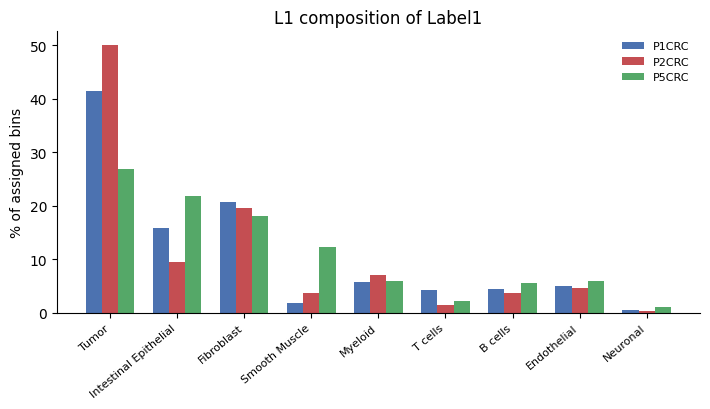

In [19]:
l1_pct = pd.DataFrame(
    {p: 100 * reports[p]["l1_n"].reindex(L1_ORDER).fillna(0) / reports[p]["n_assigned"] for p in PATIENTS}
)
l1_n = pd.DataFrame(
    {p: reports[p]["l1_n"].reindex(L1_ORDER).fillna(0).astype(int) for p in PATIENTS}
)
print("L1 counts (Label1 mapped)")
print(l1_n.to_string())
print("\nL1 % of assigned bins")
print(l1_pct.round(2).to_string())


fig, ax = plt.subplots(figsize=(7.2, 4.2))
x = np.arange(len(L1_ORDER))
w = 0.24
for i, p in enumerate(PATIENTS):
    ax.bar(
        x + (i - 1) * w, l1_pct[p].to_numpy(), width=w, label=p, color=PATIENT_COLORS[p]
    )
ax.set_xticks(x)
ax.set_xticklabels(L1_ORDER, rotation=40, ha="right", fontsize=8)
ax.set_ylabel("% of assigned bins")
ax.set_title("L1 composition of Label1")
ax.legend(frameon=False, fontsize=8)
fig.tight_layout()
plt.show()


In [20]:
print("Summary")
print("- Flex 2025 Keep: "
      f"L1={keep['Level1'].nunique()}  L2={keep['Level2'].nunique()}  "
      f"majority map covers all {len(l2_to_l1)} L2 types.")
low_names = maj.loc[maj['purity'] < 0.80, 'Level2'].tolist()
print(f"- Ambiguous L2 (purity<0.80): {low_names or '(none)'}")
print("- Deconvolution L2 names match Flex 2025 (not 2024: 2024 uses "
      "'CD8 Cytotoxic T cell' and lacks Memory B / NK / Tumor IV / …).")
print("- One cell type per bin: DeconvolutionLabel1 (L2) → L1_from_Label1 (L1). "
      "DeconvolutionLabel2 is ignored.")
eq_l2 = all(reports[p]["l2_label1"] == reports["P1CRC"]["l2_label1"] for p in PATIENTS)
eq_l1 = all(reports[p]["l1_label1"] == reports["P1CRC"]["l1_label1"] for p in PATIENTS)
print(f"- P1/P2/P5 Label1 L2 sets identical: {eq_l2}  (all {len(reports['P1CRC']['l2_label1'])} types)")
print(f"- P1/P2/P5 mapped L1 sets identical: {eq_l1}  (all {len(reports['P1CRC']['l1_label1'])} types)")
print("- Abundances are NOT the same: P1 Label1 is Tumor II–heavy, "
      "P2 Tumor III–heavy, P5 Tumor IV / Goblet / vSM–heavy.")


Summary
- Flex 2025 Keep: L1=9  L2=38  majority map covers all 38 L2 types.
- Ambiguous L2 (purity<0.80): ['Myofibroblast', 'Epithelial', 'vSM', 'NK', 'Proliferating Immune II']
- Deconvolution L2 names match Flex 2025 (not 2024: 2024 uses 'CD8 Cytotoxic T cell' and lacks Memory B / NK / Tumor IV / …).
- One cell type per bin: DeconvolutionLabel1 (L2) → L1_from_Label1 (L1). DeconvolutionLabel2 is ignored.
- P1/P2/P5 Label1 L2 sets identical: True  (all 38 types)
- P1/P2/P5 mapped L1 sets identical: True  (all 9 types)
- Abundances are NOT the same: P1 Label1 is Tumor II–heavy, P2 Tumor III–heavy, P5 Tumor IV / Goblet / vSM–heavy.


## 3. Spatial annotation (`P{1,2,5}CRC_Metadata.parquet`)

Same parquet tables as sections 1–2. Besides RCTD labels they include `X`/`Y`
and extra annotations:

| Column | Meaning |
|--------|---------|
| `Periphery` | `Tumor` / `50 micron` (tumor rim) / `Tissue` (rest of on-tissue) |
| `UnsupervisedL1` / `L2` | Per-section clustering (not Flex RCTD) |
| `MacrophageSubtype` | Tumor-periphery macrophages: `SPP1+` or `SELENOP+` |
| `GobletSubcluster` | Goblet bins used in paper Figure 5 |

Plots below use on-tissue bins only (`tissue == 1`). Cell type is still
`DeconvolutionLabel1`, shown as mapped L1 (`L1_from_Label1`).


In [21]:
## bin_meta was loaded from PxCRC_Metadata.parquet in section 1
p2_meta = bin_meta["P2CRC"]
print("P2CRC_Metadata.parquet:", p2_meta.shape)
print("columns:", list(p2_meta.columns))
p2_meta.head()


P2CRC_Metadata.parquet: (702244, 14)
columns: ['barcode', 'tissue', 'X', 'Y', 'DeconvolutionClass', 'DeconvolutionLabel1', 'DeconvolutionLabel2', 'Periphery', 'UnsupervisedL1', 'UnsupervisedL2', 'MacrophageSubtype', 'GobletSubcluster', 'L1_from_Label1', 'unmapped_L2']


,barcode,tissue,X,Y,DeconvolutionClass,DeconvolutionLabel1,DeconvolutionLabel2,Periphery,UnsupervisedL1,UnsupervisedL2,MacrophageSubtype,GobletSubcluster,L1_from_Label1,unmapped_L2
0,s_008um_00000_00000-1,1,323.656687,-178.351988,None,None,None,Tissue,Smooth Muscle,SmoothMuscle-0,None,None,NaN,False
1,s_008um_00000_00001-1,1,323.889508,-178.355054,singlet,Pericytes,Endothelial,Tissue,Unknown,Endothelial-0,None,None,Fibroblast,False
2,s_008um_00000_00002-1,1,324.122329,-178.358120,None,None,None,Tissue,Endothelial,Endothelial-2,None,None,NaN,False
3,s_008um_00000_00003-1,1,324.355150,-178.361186,None,None,None,Tissue,Unknown,Unknown-3,None,None,NaN,False
4,s_008um_00000_00004-1,1,324.587971,-178.364252,None,None,None,Tissue,Unknown,Unknown-3,None,None,NaN,False


In [22]:
## Spatial maps from PxCRC_Metadata.parquet (8 µm)
p2_meta = bin_meta["P2CRC"]
print(periphery_summary(bin_meta).to_string(index=False))


patient  on_tissue  Tumor  50 micron  Tissue  SPP1+  SELENOP+  Goblet bins
  P1CRC     507684 126732      32835  348117    166       629        36182
  P2CRC     545913 213815      64574  267524    935       858        26625
  P5CRC     541968  81834      53517  406617      0       196        55038


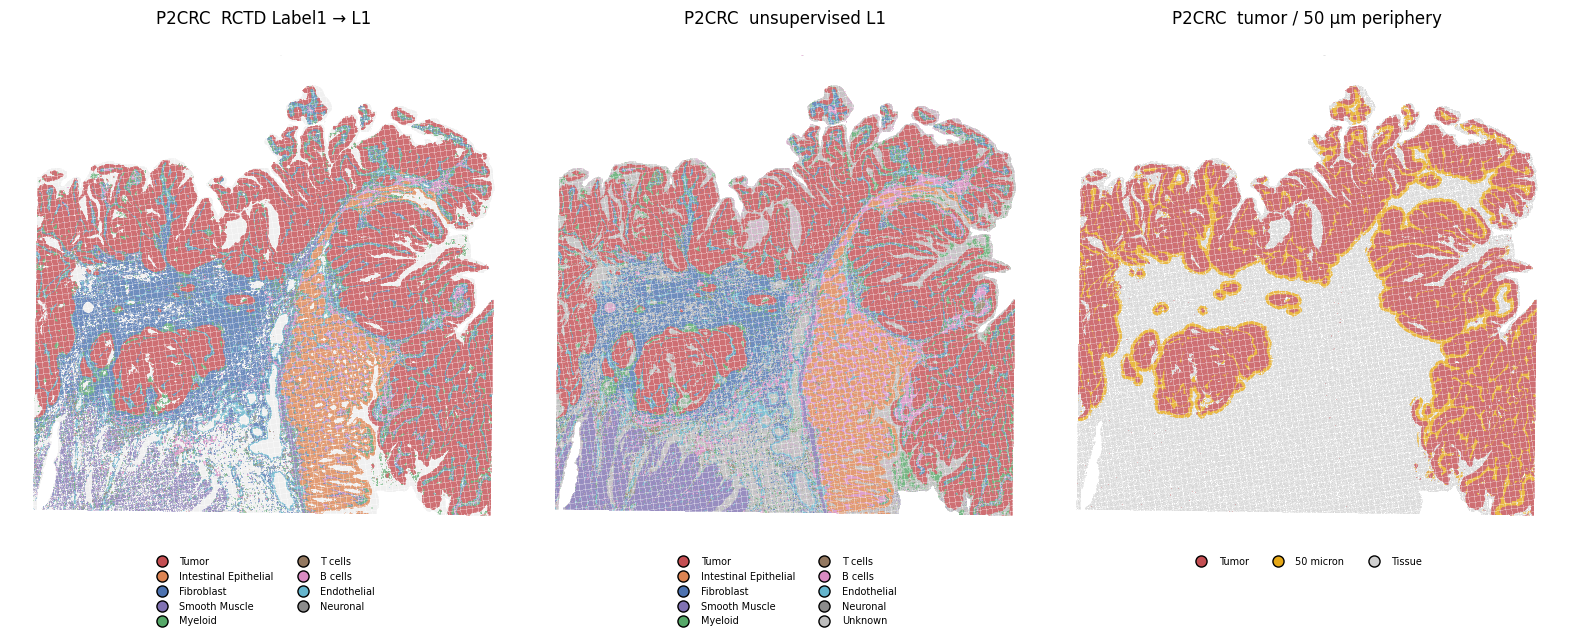

In [23]:
fig, axes = plt.subplots(1, 3, figsize=(15.8, 6.2))
scatter_cats(axes[0], p2_meta, "L1_from_Label1", L1_COLORS)
axes[0].set_title("P2CRC  RCTD Label1 → L1")
axis_legend(axes[0], L1_COLORS, ncol=2)
scatter_cats(axes[1], p2_meta, "UnsupervisedL1", UNSUP_COLORS)
axes[1].set_title("P2CRC  unsupervised L1")
axis_legend(axes[1], UNSUP_COLORS, ncol=2)
scatter_periphery(axes[2], p2_meta)
axes[2].set_title("P2CRC  tumor / 50 µm periphery")
axis_legend(axes[2], PERIPH_COLORS, ncol=3)
fig.tight_layout()
plt.show()


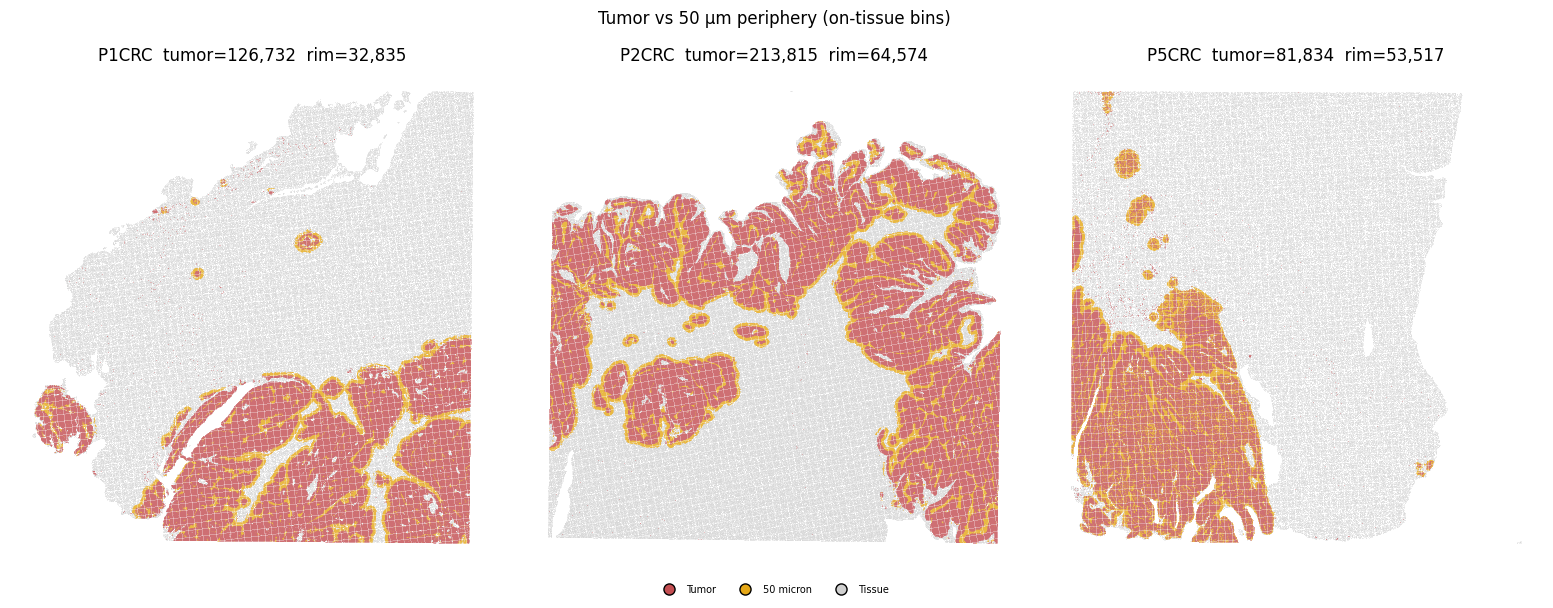

In [24]:
fig, axes = plt.subplots(1, 3, figsize=(15.8, 5.6))
for ax, p in zip(axes, PATIENTS):
    scatter_periphery(ax, bin_meta[p])
    on = on_tissue(bin_meta[p])
    n_tum = int((on["Periphery"] == "Tumor").sum())
    n_rim = int((on["Periphery"] == "50 micron").sum())
    ax.set_title(f"{p}  tumor={n_tum:,}  rim={n_rim:,}")
axis_legend(axes[1], PERIPH_COLORS, ncol=3)
fig.suptitle("Tumor vs 50 µm periphery (on-tissue bins)", y=1.02)
fig.tight_layout()
plt.show()


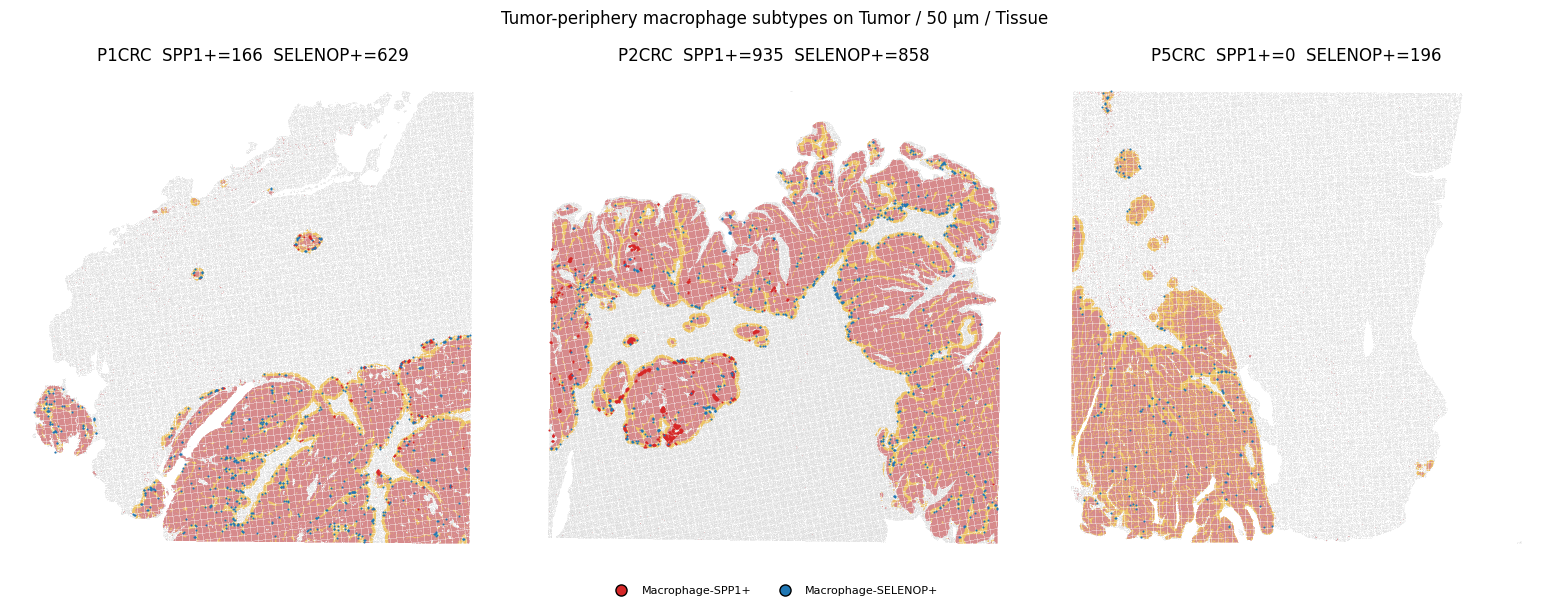

In [25]:
fig, axes = plt.subplots(1, 3, figsize=(15.8, 5.6))
for ax, p in zip(axes, PATIENTS):
    df = bin_meta[p]
    scatter_periphery(ax, df, s=0.08)
    on = on_tissue(df)
    for lab, color in MAC_COLORS.items():
        sub = on.loc[on["MacrophageSubtype"] == lab]
        if sub.empty:
            continue
        ax.scatter(sub["X"], sub["Y"], s=2.2, c=color, linewidths=0, rasterized=True, zorder=3)
    n_spp1 = int((df["MacrophageSubtype"] == "Macrophage-SPP1+").sum())
    n_sel = int((df["MacrophageSubtype"] == "Macrophage-SELENOP+").sum())
    ax.set_title(f"{p}  SPP1+={n_spp1:,}  SELENOP+={n_sel:,}")
axis_legend(axes[1], MAC_COLORS, ncol=2, fontsize=8)
fig.suptitle("Tumor-periphery macrophage subtypes on Tumor / 50 µm / Tissue", y=1.02)
fig.tight_layout()
plt.show()


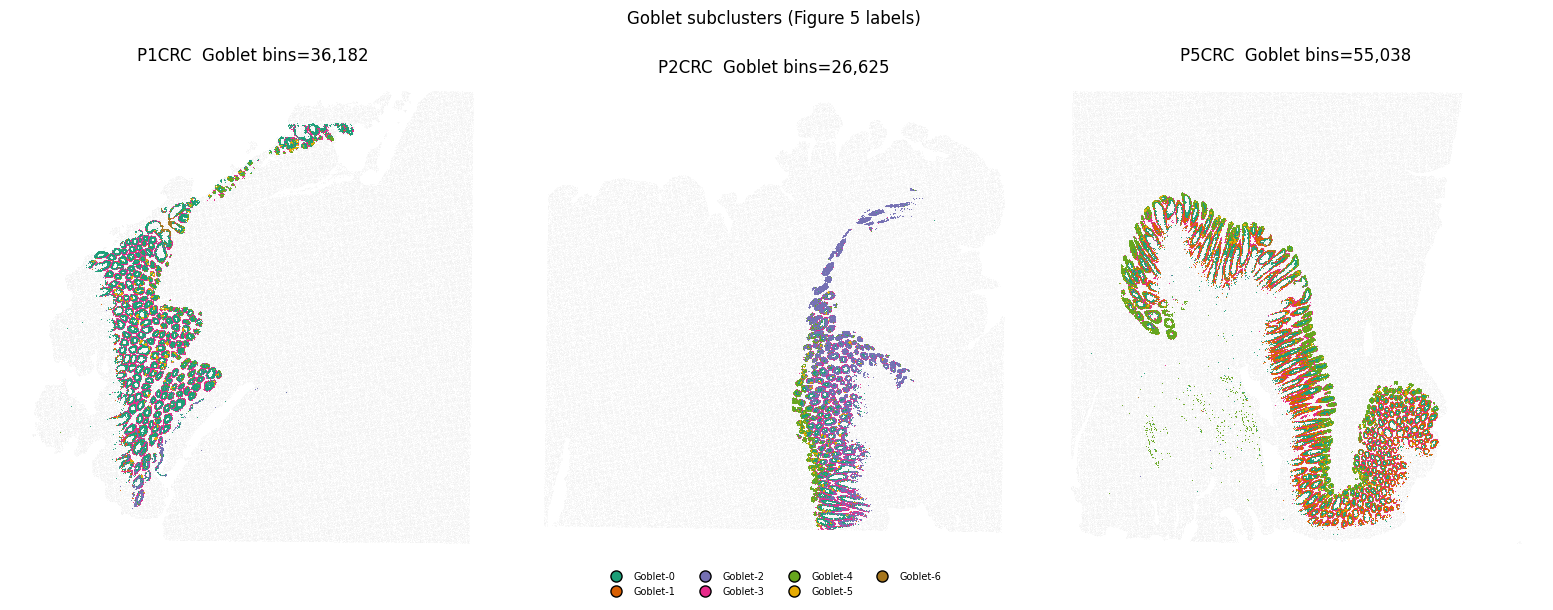

In [26]:
fig, axes = plt.subplots(1, 3, figsize=(15.8, 5.6))
used_goblet = []
for ax, p in zip(axes, PATIENTS):
    df = bin_meta[p]
    scatter_cats(
        ax, df, "GobletSubcluster", GOBLET_COLORS, s=0.1, highlight_s=0.45, bg_color="#ececec"
    )
    n = int(df["GobletSubcluster"].notna().sum())
    ax.set_title(f"{p}  Goblet bins={n:,}")
    present = [k for k in GOBLET_COLORS if (df["GobletSubcluster"] == k).any()]
    used_goblet.extend(present)
goblet_shown = {k: GOBLET_COLORS[k] for k in GOBLET_COLORS if k in set(used_goblet)}
axis_legend(axes[1], goblet_shown, ncol=4, fontsize=7)
fig.suptitle("Goblet subclusters (Figure 5 labels)", y=1.02)
fig.tight_layout()
plt.show()


## 4. Xenium vs Visium HD (P2, then P1 / P5)

Serial FFPE sections were also profiled with Xenium (paper companion).
`data/Xemium/CRC/Xenium_Visium_Alignment/Xenium_P{1,2,5}_cell_info.csv` are the
GitHub alignment tables: centroids, counts, areas, and coordinates already
transformed into Visium HD full-res pixel space (`x/y_centroid_visium_scale`).
**There is no biological cell-type column** — Xenium here is spatial / QC
validation, not Flex label transfer.

Each Xenium cell is assigned to the nearest on-tissue 8 µm bin if the distance
is < one bin diameter (`spot_diameter_fullres`). Cell type of that bin is
still `DeconvolutionLabel1` → `L1_from_Label1`.


In [27]:
## Xenium_P2_cell_info.csv — paper Visium-aligned cell table (no cell type)
xen_p2 = load_xenium_cells("P2CRC", paths)
print("Xenium P2:", xen_p2.shape)
print("columns:", list(xen_p2.columns))
print(
    xen_p2[["transcript_counts", "cell_area", "nucleus_area"]].describe().round(2).to_string()
)
print(f"nucleus_area NA: {xen_p2['nucleus_area'].isna().mean():.2%}")
print("No cell-type column:", [c for c in xen_p2.columns if "type" in c.lower() or "label" in c.lower()] or "(none)")
xen_p2.head()


Xenium P2: (1105615, 10)
columns: ['cell_id', 'x_centroid', 'y_centroid', 'transcript_counts', 'total_counts', 'cell_area', 'nucleus_area', 'x_centroid_visium_scale', 'y_centroid_visium_scale', 'patient']
       transcript_counts   cell_area  nucleus_area
count         1105615.00  1105615.00    1057340.00
mean              124.17       69.37         27.93
std               109.74       50.03         19.73
min                 0.00        2.12          1.76
25%                53.00       36.03         14.18
50%                94.00       55.81         23.17
75%               160.00       87.58         35.54
max              2363.00      984.59        337.77
nucleus_area NA: 4.37%
No cell-type column: (none)


,cell_id,x_centroid,y_centroid,transcript_counts,total_counts,cell_area,nucleus_area,x_centroid_visium_scale,y_centroid_visium_scale,patient
0,aaaaamnm-1,2643.596924,5070.718262,56,56,22.803907,14.495157,58157.64,9341.189,P2CRC
1,aaaaaoag-1,2655.368896,5068.615723,108,108,43.575783,25.106876,58165.87,9384.208,P2CRC
2,aaaabfdb-1,2638.893311,5076.776855,83,83,30.525626,16.843282,58135.24,9324.235,P2CRC
3,aaaabhag-1,2646.595459,5076.092773,136,136,62.135002,24.474688,58138.09,9352.413,P2CRC
4,aaaacbml-1,2638.368408,5072.426270,57,57,26.642188,22.803907,58151.15,9322.117,P2CRC


In [28]:
p2_map = map_xenium_to_bins("P2CRC", bin_meta["P2CRC"], paths, xen=xen_p2)
print(
    f"P2CRC Xenium cells={p2_map['n_cells']:,}  "
    f"in Visium bbox={p2_map['n_bbox']:,} ({100*p2_map['n_bbox']/p2_map['n_cells']:.1f}%)  "
    f"mapped <1 bin={p2_map['n_mapped']:,} ({100*p2_map['n_mapped']/p2_map['n_cells']:.1f}%)"
)
print(
    f"median distance: bbox {p2_map['median_um_bbox']:.2f} µm,  "
    f"mapped {p2_map['median_um_mapped']:.2f} µm  "
    f"(bin diameter {p2_map['bin_px']*p2_map['mpp']:.2f} µm)"
)
print(f"unique on-tissue bins hit: {p2_map['n_bins_hit']:,} / {(bin_meta['P2CRC']['tissue']==1).sum():,}")
print("cells / hit bin:\n", p2_map["hit"]["nearest_barcode"].value_counts().describe().round(3).to_string())
print("\nMapped cells by RCTD class:")
print(p2_map["hit"]["DeconvolutionClass"].value_counts(dropna=False).to_string())
print("\nMapped cells by Periphery:")
print(p2_map["hit"]["Periphery"].value_counts(dropna=False).to_string())


P2CRC Xenium cells=1,105,615  in Visium bbox=319,316 (28.9%)  mapped <1 bin=314,148 (28.4%)
median distance: bbox 3.22 µm,  mapped 3.19 µm  (bin diameter 8.00 µm)
unique on-tissue bins hit: 250,099 / 545,913
cells / hit bin:
 count    250099.000
mean          1.256
std           0.504
min           1.000
25%           1.000
50%           1.000
75%           1.000
max           6.000

Mapped cells by RCTD class:
DeconvolutionClass
singlet              209779
doublet_certain       36064
doublet_uncertain     28987
None                  23672
reject                15646

Mapped cells by Periphery:
Periphery
Tumor        159312
Tissue       102510
50 micron     52326


In [29]:
## P2 Xenium cells: transferred Visium HD Label1 + map_status (singlet / unmapped / …)
xen_p2_labeled = label_xenium_from_visium(p2_map["xen"], bin_meta["P2CRC"])

print("P2 Xenium map_status")
print(map_status_table(xen_p2_labeled).round(2).to_string())
print(
    f"\nLabel1_from_VisiumHD filled: {xen_p2_labeled['Label1_from_VisiumHD'].notna().sum():,} / {len(xen_p2_labeled):,}"
)
print("singlet Label1 (top):")
print(
    xen_p2_labeled.loc[xen_p2_labeled["map_status"] == "singlet", "Label1_from_VisiumHD"]
    .value_counts()
    .head(10)
    .to_string()
)
xen_p2_labeled[
    ["cell_id", "map_status", "Label1_from_VisiumHD", "DeconvolutionClass", "dist_um", "nearest_barcode"]
].head()


P2 Xenium map_status
                        n    pct
map_status                      
singlet            209779  18.97
doublet_certain     36064   3.26
doublet_uncertain   28987   2.62
reject              15646   1.42
mapped_no_label     23672   2.14
unmapped           791467  71.59

Label1_from_VisiumHD filled: 290,476 / 1,105,615
singlet Label1 (top):
Label1_from_VisiumHD
Tumor III                    146993
Goblet                        17397
CAF                           15622
Enterocyte                     4808
Endothelial                    4681
vSM                            3813
Plasma                         3325
Macrophage                     1998
Neutrophil                     1727
Proliferating Macrophages      1584


,cell_id,map_status,Label1_from_VisiumHD,DeconvolutionClass,dist_um,nearest_barcode
0,aaaaamnm-1,singlet,Tumor III,singlet,2.992146,s_008um_00454_00596-1
1,aaaaaoag-1,reject,Myofibroblast,reject,2.857870,s_008um_00452_00596-1
2,aaaabfdb-1,singlet,Tumor III,singlet,3.271588,s_008um_00454_00595-1
3,aaaabhag-1,singlet,Tumor III,singlet,3.455536,s_008um_00453_00595-1
4,aaaacbml-1,singlet,Tumor III,singlet,5.170815,s_008um_00454_00595-1


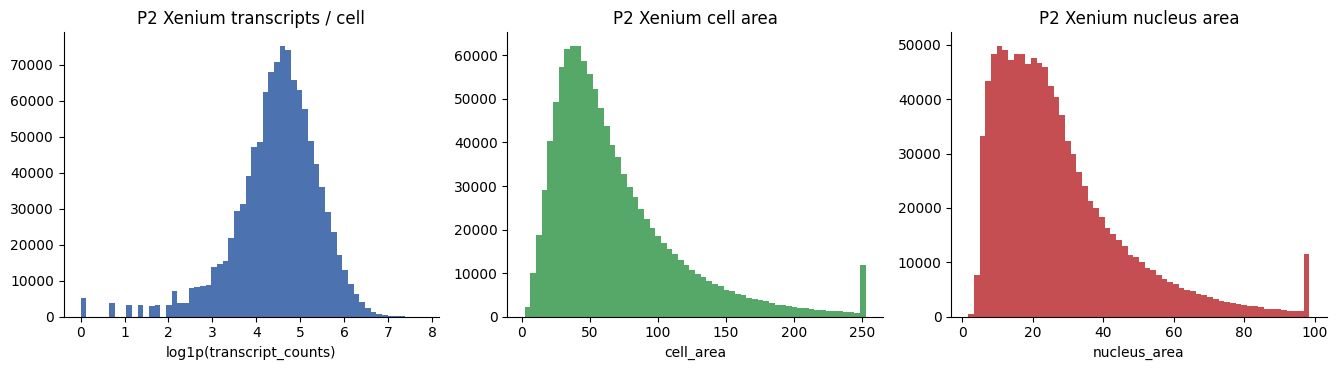

In [30]:
fig, axes = plt.subplots(1, 3, figsize=(13.5, 3.8))
axes[0].hist(np.log1p(xen_p2["transcript_counts"]), bins=60, color="#4c72b0", rasterized=True)
axes[0].set_xlabel("log1p(transcript_counts)")
axes[0].set_title("P2 Xenium transcripts / cell")
axes[1].hist(xen_p2["cell_area"].clip(upper=np.nanpercentile(xen_p2["cell_area"], 99)), bins=60, color="#55a868", rasterized=True)
axes[1].set_xlabel("cell_area")
axes[1].set_title("P2 Xenium cell area")
na_nuc = xen_p2["nucleus_area"].dropna()
axes[2].hist(na_nuc.clip(upper=np.nanpercentile(na_nuc, 99)), bins=60, color="#c44e52", rasterized=True)
axes[2].set_xlabel("nucleus_area")
axes[2].set_title("P2 Xenium nucleus area")
fig.tight_layout()
plt.show()


L1 composition (mapped Xenium cells vs all Visium assigned bins)
                       Xenium cells %  Visium bins %
L1_from_Label1                                      
Tumor                           55.37          50.12
Intestinal Epithelial            9.04           9.44
Fibroblast                      15.25          19.56
Smooth Muscle                    1.93           3.69
Myeloid                          7.68           7.12
T cells                          1.39           1.43
B cells                          4.76           3.70
Endothelial                      4.32           4.64
Neuronal                         0.25           0.30

chi2 L1 (Xenium cells vs Visium bins): chi2=5145.8  df=8  p=0.00e+00

Periphery composition
           Xenium cells %  Visium on-tissue bins %
Periphery                                         
Tumor               50.71                    39.17
50 micron           16.66                    11.83
Tissue              32.63                    49.00
chi2

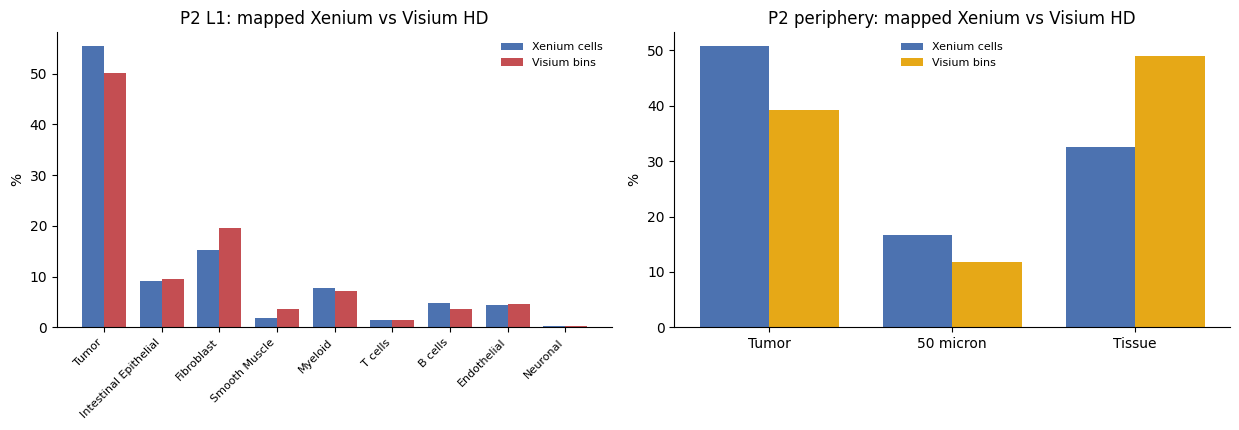

In [31]:
# Cell-weighted L1 / Periphery of mapped Xenium cells vs Visium HD assigned bins
comp_out = compare_mapped_vs_visium(p2_map["hit"], bin_meta["P2CRC"])
comp = comp_out["l1"]
per = comp_out["periphery"]
chi2, dof, pval = comp_out["l1_chi2"]
chi2p, dofp, pp = comp_out["periphery_chi2"]

print("L1 composition (mapped Xenium cells vs all Visium assigned bins)")
print(comp.round(2).to_string())
print(f"\nchi2 L1 (Xenium cells vs Visium bins): chi2={chi2:.1f}  df={dof}  p={pval:.2e}")
print("\nPeriphery composition")
print(per.round(2).to_string())
print(f"chi2 Periphery: chi2={chi2p:.1f}  df={dofp}  p={pp:.2e}")

fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.4))
x = np.arange(len(L1_ORDER))
w = 0.38
axes[0].bar(x - w/2, comp["Xenium cells %"], w, color="#4c72b0", label="Xenium cells")
axes[0].bar(x + w/2, comp["Visium bins %"], w, color="#c44e52", label="Visium bins")
axes[0].set_xticks(x)
axes[0].set_xticklabels(L1_ORDER, rotation=45, ha="right", fontsize=8)
axes[0].set_ylabel("%")
axes[0].set_title("P2 L1: mapped Xenium vs Visium HD")
axes[0].legend(frameon=False, fontsize=8)
x2 = np.arange(len(PERIPH_ORDER))
axes[1].bar(x2 - w/2, per["Xenium cells %"], w, color="#4c72b0", label="Xenium cells")
axes[1].bar(x2 + w/2, per["Visium on-tissue bins %"], w, color="#e6a817", label="Visium bins")
axes[1].set_xticks(x2)
axes[1].set_xticklabels(PERIPH_ORDER)
axes[1].set_ylabel("%")
axes[1].set_title("P2 periphery: mapped Xenium vs Visium HD")
axes[1].legend(frameon=False, fontsize=8)
fig.tight_layout()
plt.show()


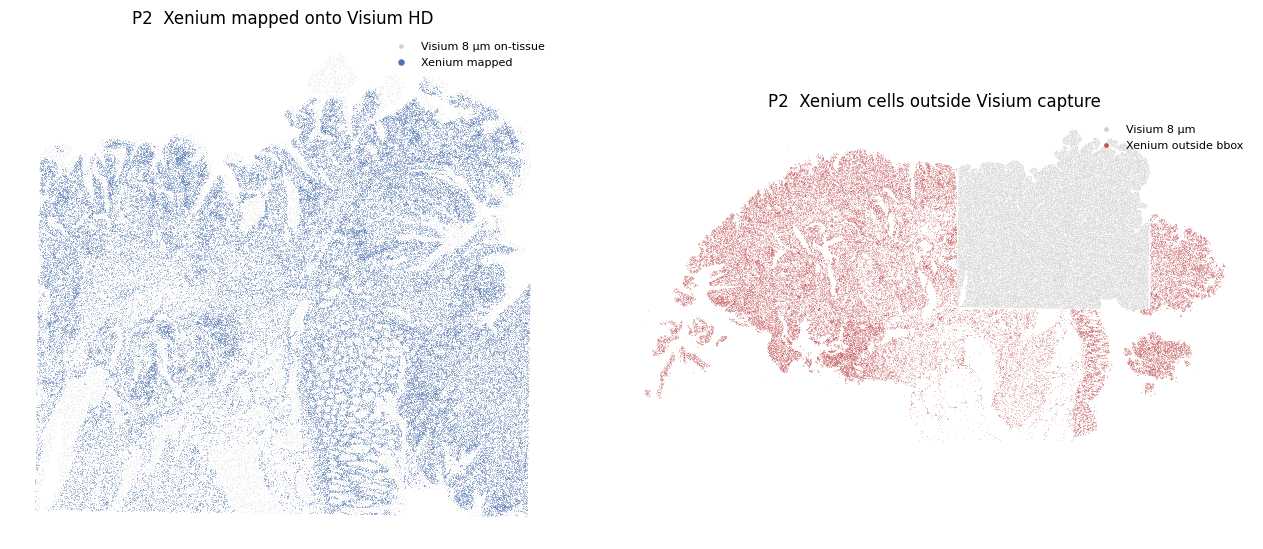

In [32]:
# Spatial: Visium on-tissue bins vs Xenium cells in Visium pixel space
tp = p2_map["tp"]
on = tp.loc[tp["in_tissue"] == 1]
xen = p2_map["xen"]
mapped = xen.loc[xen["mapped_to_bin"]]
outside = xen.loc[~xen["in_visium_bbox"]]

fig, axes = plt.subplots(1, 2, figsize=(13.2, 5.6))
axes[0].scatter(subsample_df(on)["pxl_col_in_fullres"], subsample_df(on)["pxl_row_in_fullres"], s=0.08, c="#d0d0d0", linewidths=0, rasterized=True, label="Visium 8 µm on-tissue")
axes[0].scatter(subsample_df(mapped)["x_centroid_visium_scale"], subsample_df(mapped)["y_centroid_visium_scale"], s=0.15, c="#4c72b0", linewidths=0, rasterized=True, label="Xenium mapped")
axes[0].set_title("P2  Xenium mapped onto Visium HD")
axes[0].set_aspect("equal")
axes[0].invert_yaxis()
axes[0].set_axis_off()
axes[0].legend(markerscale=12, frameon=False, loc="upper right", fontsize=8)

axes[1].scatter(subsample_df(on)["pxl_col_in_fullres"], subsample_df(on)["pxl_row_in_fullres"], s=0.08, c="#d0d0d0", linewidths=0, rasterized=True, label="Visium 8 µm")
axes[1].scatter(subsample_df(outside)["x_centroid_visium_scale"], subsample_df(outside)["y_centroid_visium_scale"], s=0.08, c="#c44e52", linewidths=0, rasterized=True, label="Xenium outside bbox")
axes[1].set_title("P2  Xenium cells outside Visium capture")
axes[1].set_aspect("equal")
axes[1].invert_yaxis()
axes[1].set_axis_off()
axes[1].legend(markerscale=12, frameon=False, loc="upper right", fontsize=8)
fig.tight_layout()
plt.show()


In [33]:
# P1 / P2 / P5 overlap with Visium HD (same mapping rule)
rows = []
xenium_maps = {"P2CRC": p2_map}
for p in PATIENTS:
    m = p2_map if p == "P2CRC" else map_xenium_to_bins(p, bin_meta[p], paths)
    xenium_maps[p] = m
    rows.append(overlap_row(m, bin_meta[p]))
overlap = pd.DataFrame(rows)
print(overlap.round(2).to_string(index=False))

print("\nTop Label1 of mapped Xenium cells")
for p in PATIENTS:
    top = xenium_maps[p]["hit"]["DeconvolutionLabel1"].value_counts().head(5)
    print(f"  {p}: " + ", ".join(f"{k} ({v:,})" for k, v in top.items()))


patient  Xenium cells  in Visium bbox  bbox %  mapped <1 bin  mapped %  median µm  bins hit  Visium on-tissue  bins hit %  Visium assigned
  P1CRC       1123632          275589   24.53         272592     24.26       3.20    223129            507684       43.95           311374
  P2CRC       1105615          319316   28.88         314148     28.41       3.19    250099            545913       45.81           431004
  P5CRC       1029090          246699   23.97         244937     23.80       3.20    204602            541968       37.75           392336

Top Label1 of mapped Xenium cells
  P1CRC: Tumor II (85,064), CAF (25,769), Goblet (23,080), CD4 T cell (11,476), Mature B (10,304)
  P2CRC: Tumor III (159,312), CAF (26,170), Goblet (20,321), Endothelial (11,667), Plasma (10,124)
  P5CRC: Tumor IV (56,462), Goblet (37,280), CAF (18,802), Endothelial (11,305), vSM (10,134)


## 5. Transfer VisiumHD label to Xenium

`Xenium_P*_cell_info.csv` has no cell type. Each Xenium cell is assigned the
nearest on-tissue 8 µm Visium HD bin's `DeconvolutionLabel1` (Flex **Level2**).
**Level12** is the Flex 2025 majority parent (9 GT classes);
**Level1** collapses those into 4 coarse classes (Neuronal → Stromal).

Only RCTD **singlet** bins are written. These are transferred labels, not
Xenium ground truth (serial sections; RCTD on bins).

Workbook: `data/Xemium/CRC/Annotation/CRC_Barcode_Cell_Type_Matrices.xlsx`

| column | meaning |
|--------|---------|
| `celltype_level2` | Flex L2 (`Cluster`) |
| `celltype_level12` | Flex L1, 9 classes |
| `celltype_level1` | Epithelial / Stromal / Immune / Endothelial (Neuronal → Stromal) |

P1 / P5 sheets can be added the same way after P2 looks right.


In [34]:
## Try to transfer VisiumHD label to Xenium, taking P2_CRC as an example
from match_xenium_cells_with_visiumhd import process_patient
from crc_paths import L1_COARSE_COLORS, L1_COARSE_ORDER, L12_COLORS, L2_COLORS, L2_ORDER
from CRC_plot import scatter_cats_xy

p2_xfer = process_patient(
    "P2CRC",
    paths=paths,
    maj=maj,
    l2_to_l1=l2_to_l1,
    vis_df=bin_meta["P2CRC"],
    labeled=xen_p2_labeled,
    keep_status=("singlet",),
)
celltype_sheet = p2_xfer["celltype"]
p2_sheet = p2_xfer["sheet"]
print("\ncelltype sheet")
print(celltype_sheet.to_string(index=False))


P2CRC map_status (all Xenium cells)
                        n    pct
map_status                      
singlet            209779  18.97
doublet_certain     36064   3.26
doublet_uncertain   28987   2.62
reject              15646   1.42
mapped_no_label     23672   2.14
unmapped           791467  71.59
P2CRC → sheet P2_CRC: 209,779 cells  L2=36  L12=9  L1=4
  wrote /nobackup2/users/lingyu/Python/Hist2Pheno/data/Xemium/CRC/Annotation/CRC_Barcode_Cell_Type_Matrices.xlsx  sheets=celltype,P2_CRC

celltype sheet
celltype_level1      celltype_level12           celltype_level2
     Epithelial                 Tumor                   Tumor I
     Epithelial                 Tumor                  Tumor II
     Epithelial                 Tumor                 Tumor III
     Epithelial                 Tumor                  Tumor IV
     Epithelial                 Tumor                   Tumor V
     Epithelial Intestinal Epithelial                Enterocyte
     Epithelial Intestinal Epithelial      

In [35]:
print("P2_CRC preview")
print(p2_sheet.head().to_string(index=False))
print(f"\nP2_CRC n={len(p2_sheet):,}  L2={p2_sheet['Cluster'].nunique()}  L12={p2_sheet['celltype_level12'].nunique()}  L1={p2_sheet['celltype_level1'].nunique()}")
print("\nL1 coarse counts")
print(p2_sheet["celltype_level1"].value_counts().reindex(L1_COARSE_ORDER).to_string())
print("\nL12 (Flex 9-class) counts")
print(p2_sheet["celltype_level12"].value_counts().reindex(L1_ORDER).to_string())
print("\nL2 counts (top 15)")
print(p2_sheet["Cluster"].value_counts().head(15).to_string())
print("\nWorkbook:", p2_xfer["xlsx"])


P2_CRC preview
   Barcode   Cluster celltype_level1 celltype_level12 celltype_level2 map_status  dist_um       nearest_barcode  x_centroid  y_centroid  x_centroid_visium_scale  y_centroid_visium_scale  transcript_counts
aaaaamnm-1 Tumor III      Epithelial            Tumor       Tumor III    singlet 2.992146 s_008um_00454_00596-1 2643.596924 5070.718262                58157.640                 9341.189                 56
aaaabfdb-1 Tumor III      Epithelial            Tumor       Tumor III    singlet 3.271588 s_008um_00454_00595-1 2638.893311 5076.776855                58135.240                 9324.235                 83
aaaabhag-1 Tumor III      Epithelial            Tumor       Tumor III    singlet 3.455536 s_008um_00453_00595-1 2646.595459 5076.092773                58138.090                 9352.413                136
aaaacbml-1 Tumor III      Epithelial            Tumor       Tumor III    singlet 5.170815 s_008um_00454_00595-1 2638.368408 5072.426270                58151.150     

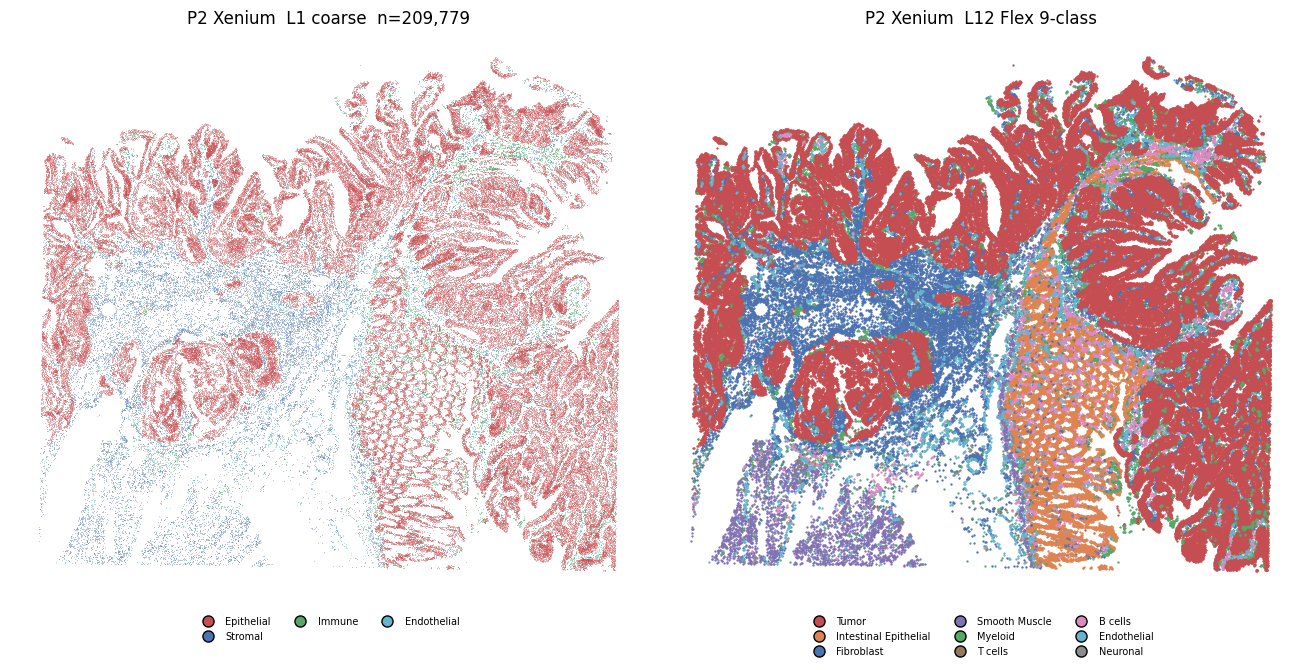

In [48]:
fig, axes = plt.subplots(1, 2, figsize=(13.2, 6.4))
scatter_cats_xy(
    axes[0],
    p2_sheet,
    "celltype_level1",
    L1_COARSE_COLORS,
    x="x_centroid_visium_scale",
    y="y_centroid_visium_scale",
)
axes[0].set_title(f"P2 Xenium  L1 coarse  n={len(p2_sheet):,}")
axes[0].invert_yaxis()
axis_legend(axes[0], L1_COARSE_COLORS, ncol=3)
scatter_cats_xy(
    axes[1],
    p2_sheet,
    "celltype_level12",
    L12_COLORS,
    x="x_centroid_visium_scale",
    y="y_centroid_visium_scale",
    s=2.8,    # default 0.15
)
axes[1].set_title("P2 Xenium  L12 Flex 9-class")
axes[1].invert_yaxis()
axis_legend(axes[1], L12_COLORS, ncol=3)
fig.tight_layout()
plt.show()


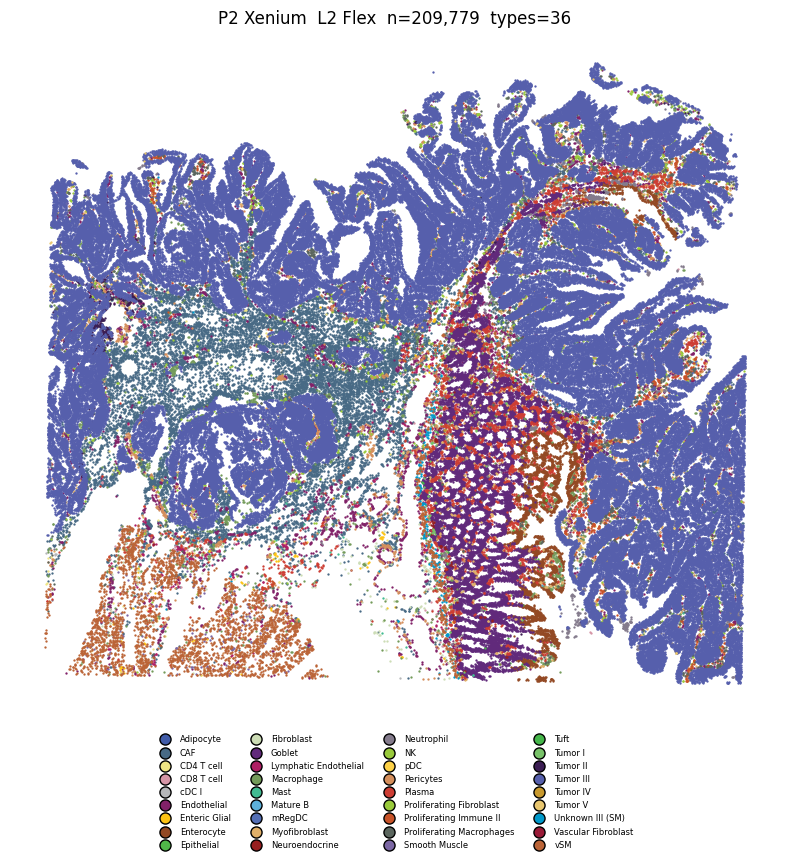

In [47]:
present_l2 = set(p2_sheet["celltype_level2"].astype(str))
l2_palette = {k: L2_COLORS[k] for k in L2_ORDER if k in present_l2}
fig2, ax2 = plt.subplots(figsize=(8.0, 8.2))
scatter_cats_xy(
    ax2,
    p2_sheet,
    "celltype_level2",
    l2_palette,
    x="x_centroid_visium_scale",
    y="y_centroid_visium_scale",
    s=2.8,    # default 0.15
)
ax2.set_title(f"P2 Xenium  L2 Flex  n={len(p2_sheet):,}  types={len(l2_palette)}")
ax2.invert_yaxis()
axis_legend(ax2, l2_palette, ncol=4, fontsize=6)
fig2.tight_layout()
plt.show()
